[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap02/cap02_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Da Captura ao Pixel - Amostragem, Quantização e Conectividade

Este capítulo aprofunda a compreensão da imagem digital, transitando da natureza física da captura para a sua representação matemática discreta. Investigamos como a luz se torna dado e como a organização espacial dos pixels define as relações de vizinhança e conectividade essenciais para algoritmos avançados de Visão Computacional.

## Objetivos

Ao final deste capítulo, você será capaz de:

- Explicar o modelo físico de formação da imagem baseado em iluminação e refletância.
- Diferenciar os mecanismos da visão humana e dos sensores digitais.
- Compreender os processos de **amostragem** (discretização do espaço) e **quantização** (discretização da intensidade).
- Descrever as relações topológicas entre pixels: vizinhança, adjacência, conectividade e distâncias.
- Realizar transformações geométricas básicas (translação, rotação, escala) preservando a qualidade.
- Visualizar na prática os efeitos da variação da resolução espacial e da profundidade de bits.

## O Olho e a Câmera - Elementos da Percepção Visual

A formação de uma imagem digital começa com a captura da luz refletida pelos objetos, como intruduzido no capítulo anterior. Tanto o olho humano quanto as câmeras digitais seguem princípios semelhantes, mas com diferenças importantes.

### Visão humana

O olho é um sistema óptico complexo: a luz atravessa a córnea, o humor aquoso, o cristalino (que ajusta o foco) e o humor vítreo até atingir a retina. Na retina, os **cones** (≈6 milhões) são responsáveis pela visão de cores (três tipos sensíveis ao vermelho, verde e azul), enquanto os **bastonetes** (≈120 milhões) operam em baixa luminosidade, fornecendo apenas intensidade. O ponto cego é a região de saída do nervo óptico, sem fotorreceptores.

### Sensores digitais

Câmeras digitais utilizam sensores **CCD** ou **CMOS** que substituem a retina. Cada elemento do sensor (fotossítio) acumula carga elétrica proporcional à luz incidente. Um **filtro de Bayer** (matriz de filtros coloridos) permite capturar as três componentes de cor. Um conversor analógico-digital (ADC) quantiza a carga em um valor numérico. Diferentemente do olho, o sensor digital tem resolução espacial fixa (número de pixels) e profundidade de bits definida (ex.: 8 bits por canal).

> **Curiosidade:** A resolução efetiva da fóvea (visão central de alta definição) é equivalente a aproximadamente 120 × 120 pixels. O processamento cerebral realiza enorme pós-processamento para gerar a percepção de alta resolução.

## O Modelo Matemático da Formação da Imagem

Uma imagem pode ser modelada como o produto de duas funções:

$$
f(x,y) = i(x,y) \cdot r(x,y)
$$ #eq-02-imagem

onde:

- $i(x,y)$ é a **iluminação** incidente sobre a cena (energia luminosa por unidade de área). Depende da fonte de luz.
- $r(x,y)$ é a **refletância** do objeto (fração da luz refletida). Depende das propriedades do material e da superfície.

Na prática, as duas componentes variam em faixas distintas: $i(x,y)$ varia lentamente no espaço, enquanto $r(x,y)$ pode variar rapidamente (texturas, bordas). O processamento de imagens frequentemente tenta separar ou compensar essas componentes (ex.: correção de iluminação não uniforme).

## Digitalização: Amostragem e Quantização

Para transformar uma cena contínua em uma imagem digital, dois processos são necessários.

### Amostragem - Discretização do espaço

A amostragem consiste em medir o valor da função $f(x,y)$ em pontos igualmente espaçados, formando uma matriz de $M$ linhas (altura) e $N$ colunas (largura). Cada elemento dessa matriz é um **pixel**. A **resolução espacial** é dada por $M \times N$. Quanto maior a resolução, mais detalhes espaciais são preservados, mas maior também o custo computacional e de armazenamento.

### Quantização - Discretização da intensidade

A quantização associa a cada pixel um valor numérico discreto, geralmente representado por um inteiro de $b$ bits. A **profundidade de bits** define o número de níveis de intensidade: $2^b$. Imagens em tons de cinza costumam usar 8 bits (256 níveis). Imagens coloridas usam três canais de 8 bits (24 bits no total).


**Ilustração:** Se usarmos apenas 1 bit por pixel (preto e branco), perdemos todos os tons intermediários. Com 2 bits (4 níveis) já se percebe degradês grosseiros. Com 8 bits, o olho humano dificilmente percebe a discretização (visão contínua).

::: {.callout-warning}
### Erro de quantização {.unnumbered}
**Erro de quantização** é a diferença entre o valor analógico real e o valor discreto atribuído. Ele se manifesta como ruído de quantização, visível em regiões com gradiente suave quando se usa poucos bits (efeito de "posterização").
:::

### Laboratório prático: Efeitos da amostragem e quantização

Os experimentos a seguir mostram como a redução da resolução espacial (subamostragem) e da profundidade de bits degradam a qualidade visual. Use o código para explorar diferentes fatores e níveis de cinza.

In [67]:
#| quarto-raw: true

import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Baixar morph.py se necessário
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

✅ Ambiente pronto


In [ ]:
#| quarto-raw: true

# Carregar imagem de exemplo (Lena)
url_lena = "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"
img_color = mm.read(url_lena)
img_gray = mm.gray(img_color)
print(f"Imagem original: {img_gray.shape}")

O experimento apresentado na @fig-02-subamostragem ilustra o compromisso entre a **resolução espacial** e o **custo de armazenamento** em memória. O código utiliza a técnica de subamostragem por fatiamento (*slicing*) para reduzir a matriz original de pixels conforme um fator $f$, resultando em uma economia drástica de memória — por exemplo, um fator $f=8$ reduz o tamanho do dado em 64 vezes ($8^2$). Para fins de comparação visual, as imagens reduzidas são restauradas às dimensões originais ($512 \times 512$) através da interpolação por **vizinho mais próximo** (`nearest`). Este processo não recupera a informação perdida, mas torna evidente o efeito de **aliasing** e a estrutura de blocos (pixelização) gerada pela baixa densidade de dados da matriz amostrada.


In [ ]:
#| label: fig-02-subamostragem
#| fig-cap: "Efeito da subamostragem. Os títulos exibem as dimensões (W x H) e o tamanho da matriz em memória (KB)."
#| echo: true
#| output: true

def subsample_simple(image, f):
    # Subamostragem via fatiamento (slicing)
    reduced = image[::f, ::f]
    
    # Cálculo de memória em KB
    mem_kb = reduced.nbytes / 1024
    label = f"{reduced.shape[1]}x{reduced.shape[0]}, {int(mem_kb)} KB\n(Fator {f})"
    
    # Restaura o tamanho para visualização (H, W originais)
    res = mm.resize(reduced, (image.shape[1], image.shape[0]), method='nearest')
    return res, label

factors = [1, 4, 8, 12]

# Gera os resultados e separa em listas para o mm.show
results = [subsample_simple(img_gray, f) for f in factors]
imgs_list = [r[0] for r in results]
titles_list = [r[1] for r in results]

mm.show(imgs_list, titles=titles_list, cols=4)

O experimento na @fig-02-quantizacao foca na **quantização de intensidade**, o processo de discretização da amplitude da função $f(x,y)$. Enquanto a subamostragem afeta a grade espacial, a redução da profundidade de bits limita a quantidade de tons de cinza disponíveis para representar o brilho.

Ao reduzir a profundidade de 8 bits (256 níveis) para valores menores, surge o efeito de **posterização**, onde os gradientes suaves de uma cena são substituídos por transições abruptas. No limite de 1 bit, a imagem torna-se estritamente binária, preservando apenas a silhueta e perdendo detalhes de textura e volume.


### Análise Técnica

* **Domínio vs. Codomínio**: Note que a resolução espacial (dimensões da matriz) permanece constante em 512x512; o que se altera é apenas o codomínio da função da imagem.
* **Constância de Memória**: Observe nos títulos que o tamanho em KB não diminui. Isso ocorre porque o NumPy armazena cada pixel quantizado em um contêiner de 8 bits (`uint8`), independentemente de o valor real ser apenas 0 ou 1.
* **Percepção**: A degradação visual torna-se crítica abaixo de 4 bits, onde o olho humano começa a perceber as "fronteiras" artificiais criadas pela falta de tons intermediários.

In [ ]:
#| label: fig-02-quantizacao
#| fig-cap: "Efeito da redução da profundidade de bits. Os títulos exibem a quantidade de bits, níveis e o tamanho em memória (KB)."
#| echo: true
#| output: true

def quantize_simple(image, bits):
    """Reduz a profundidade de bits e calcula metadados de memória."""
    levels = 2 ** bits
    # Normalização e quantização uniforme
    quantized = (np.floor(image / 256 * levels) / levels * 255).astype(np.uint8)
    
    # Cálculo de memória em KB
    mem_kb = quantized.nbytes / 1024
    label = f"{bits} bits ({levels} níveis)\n{int(mem_kb)} KB"
    
    return quantized, label

# Lista de bits para teste (8 é o padrão, 1 é o binário)
bits_test = [8, 4, 2, 1]

# Gera os resultados e separa em listas para o mm.show
results_q = [quantize_simple(img_gray, b) for b in bits_test]
imgs_q = [r[0] for r in results_q]
titles_q = [r[1] for r in results_q]

mm.show(imgs_q, titles=titles_q, cols=4)

In [ ]:
# Exemplo de compactação real para economia de memória
import numpy as np

# Imagem binária em uint8 (512x512)
img_uint8 = np.zeros((512, 512), dtype=np.uint8) 
print(f"Tamanho uint8: {img_uint8.nbytes / 1024} KB") # 256 KB

# Imagem compactada (Bit-packing)
img_packed = np.packbits(img_uint8)
print(f"Tamanho Compactado: {img_packed.nbytes / 1024} KB") # 32 KB

A limitação de tipos de dados menores que um byte no ecossistema Python/NumPy deve-se à arquitetura de hardware, que endereça a memória em blocos de 8 bits (Bytes). Para que se mantenha a compatibilidade com o OpenCV e se garanta a eficiência, mapeiam-se até mesmo elementos binários para contêineres de 1 byte (`uint8` ou `bool8`).

Embora linguagens como ANSI C permitam a compactação de 8 pixels por byte (*bit-packing*), tal abordagem exige a descompactação constante para cálculos e impõe alta complexidade na manipulação de ponteiros. Conforme a @tbl-02-dados, privilegia-se o uso de `uint8` pela facilidade no acesso a vizinhos e pela versatilidade em transformações geométricas. Além disso, métodos nativos do NumPy e OpenCV executam o processamento internamente em baixo nível (C/C++), o que torna operações vetorizadas mais rápidas do que implementações manuais com laços aninhados em Python.

| Característica | Python (NumPy/OpenCV) | ANSI C (Bit-packing) |
| --- | --- | --- |
| **Menor Unidade** | 1 Byte (8 bits) | 1 Bit |
| **Memória (Binária)** | 256 KB (para 512x512) | 32 KB (para 512x512) |
| **Velocidade** | Alta (Vetorização em C) | Variável (Lenta se houver bit-shift) |
| **Complexidade** | Baixa: Métodos prontos | Alta: Ponteiros e Máscaras |

: Comparativo entre estratégias de compactação e eficiência de processamento. {#tbl-02-dados}

## Relações entre Pixels - Topologia da Imagem

Os pixels não são elementos isolados; suas posições relativas definem importantes conceitos para processamento.

### Vizinhança

Dado um pixel de coordenadas $(x,y)$, definem-se dois tipos principais de vizinhança (para imagens em $grid$ retangular):

- **Vizinhança-4** (von Neumann): inclui os pixels nas posições $(x-1,y)$, $(x+1,y)$, $(x,y-1)$, $(x,y+1)$.
- **Vizinhança-8** (Moore): inclui todos os oito pixels adjacentes (acrescenta os quatro diagonais).

A escolha da vizinhança influencia operações como detecção de bordas, cálculo de gradientes e conectividade.

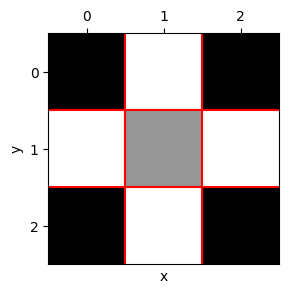

In [18]:
#| label: fig-02-vizinhanca
#| fig-cap: "Ilustração de vizinhanças 4 em uma matriz 3x3. No centro (1,1), o pixel de interesse."
#| echo: true
#| output: true

# Criação de uma matriz 3x3 para exemplo topológico
viz = np.zeros((3, 3), dtype='uint8')

# Pixel central (p)
viz[1, 1] = 150 

# Definindo Vizinhança-4 (N4) com valor diferente para destaque
viz[0, 1] = viz[2, 1] = viz[1, 0] = viz[1, 2] = 255

# Exibição da matriz para análise de coordenadas
mm.drawImagePlt(viz)

### Adjacência, conectividade e caminhos

Dois pixels são **adjacentes** se estão em contato segundo uma vizinhança definida **e** satisfazem um critério de valor (ex.: mesmo nível de intensidade). Uma **conectividade** define uma relação de equivalência entre pixels que formam uma região conexa. Um **caminho** é uma sequência de pixels adjacentes.

A conectividade-4 e conectividade-8 podem produzir resultados diferentes na segmentação e no cálculo de componentes conexas (etiquetagem). Por exemplo, um padrão de tabuleiro de xadrez pode ser completamente desconexo em 4-vizinhança, mas totalmente conexo em 8-vizinhança.

### Distâncias entre pixels

As métricas de distância são fundamentais para quantificar a proximidade física e a conectividade entre os elementos que compõem a grade digital. Conforme demonstrado na @tbl-02-distancias, a escolha da métrica define o custo de deslocamento entre pixels e altera o comportamento de algoritmos de segmentação e análise morfológica.

Para medir a distância entre dois pixels $p(x_1, y_1)$ e $q(x_2, y_2)$, utilizam-se diferentes funções métricas que impõem restrições de movimento distintas sobre o *grid*:

| Métrica | Definição | Interpretação |
|:--------|:----------|:--------------|
| **Euclidiana** | $\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$ | Distância em linha reta (contínua) |
| ***Manhattan* (*City block*)** | $|x_1-x_2| + |y_1-y_2|$ | Movimentos horizontais + verticais |
| ***Chebyshev* (Tabuleiro)** | $\max(|x_1-x_2|, |y_1-y_2|)$ | Movimentos incluindo diagonais |

: Comparativo de métricas de distância aplicadas à malha de pixels. {#tbl-02-distancias}

Essas distâncias são aplicadas em diversos contextos de PDI, incluindo algoritmos de interpolação geométrica, transformadas de distância, crescimento de regiões e análise de formas.

::: {.callout-note}

### Exemplo prático

Considerando dois pixels com deslocamentos relativos $\Delta x = 3$ e $\Delta y = 4$:

* **Euclidiana**: $\sqrt{3^2 + 4^2} = 5$ (hipotenusa do triângulo retângulo).
* ***Manhattan***: $3 + 4 = 7$ (soma dos catetos).
* ***Chebyshev***: $\max(3, 4) = 4$ (predomínio do maior deslocamento).
:::

## Armazenamento de Imagens

A escolha do formato de arquivo é um passo decisivo no fluxo de processamento, pois determina como os dados de amostragem e quantização serão preservados ou descartados. Conforme se apresenta na @tbl-02-formatos, cada extensão equilibra de forma distinta a fidelidade dos dados e a eficiência de armazenamento.

As imagens digitais podem ser armazenadas em diversos formatos, cada um com características que impactam o processamento posterior:

| Formato | Características | Uso típico |
| --- | --- | --- |
| **PGM** | Formato simples de mapa de cinzas (texto ou binário). | Pesquisa acadêmica e ferramentas Unix. |
| **BMP** | Não comprimido (ou compressão simples). | Windows, aplicações legado. |
| **PNG** | Compressão sem perdas (*lossless*). | Web, imagens com transparência. |
| **JPEG** | Compressão com perdas (*lossy*), ideal para fotografias. | Fotos, imagens médicas (uso moderado). |
| **TIFF** | Suporta múltiplas camadas e compressão variada. | Editoração, arquivamento. |
| **RAW** | Dados brutos (sensor ou matriz sem cabeçalho). | Fotografia profissional e exames médicos. |

: Principais formatos de armazenamento e suas aplicações em PDI. {#tbl-02-formatos}

Os metadados de uma imagem incluem parâmetros como largura, altura, profundidade de bits e codificação de cor. Em formatos científicos, preservam-se também informações de calibração e detalhes da captura. Ao utilizar-se a função `mm.read()`, a biblioteca `morph` preserva automaticamente esses dados para que se respeitem as propriedades originais da imagem.

Em contextos científicos e hospitalares, privilegia-se o padrão **DICOM** para garantir que não haja perda de precisão diagnóstica. Repositórios públicos como o **[The Cancer Imaging Archive (TCIA)](https://www.cancerimagingarchive.net/)**, o **[Alzheimer’s Disease Neuroimaging Initiative (ADNI)](https://adni.loni.usc.edu/)** e o **[PhysioNet](https://physionet.org/)** disponibilizam vastos conjuntos de dados neste formato, incluindo metadados clínicos anonimizados que são essenciais para a investigação científica.


In [68]:
#| label: fig-01-natureza
#| fig-cap: "APA Quilombos do Médio Ribeira - Barbudo-rajado. Crédito: Thomas Fuhrmann (CC BY-SA 4.0)."
#| echo: true

from PIL.ExifTags import TAGS

url = "https://upload.wikimedia.org/wikipedia/commons/c/c5/Area_de_Prote%C3%A7%C3%A3o_Ambiental_Quilombos_do_M%C3%A9dio_Ribeira_-_Thomas-Fuhrmann_%282023-_02%29_Malacoptila_striata.jpg"

# 1. Obter objeto com informações de captura
img_obj = mm.read(url, info=True)
exif = img_obj._getexif()

if exif:
    # 2. Extração de Hardware e Tempo
    dados = {TAGS[k]: v for k, v in exif.items() if k in TAGS and TAGS[k] in ['Make', 'Model', 'DateTime']}
    print(f"Hardware/Tempo: {dados}")

    # 3. Processamento de GPS (Tag 34853)
    gps = exif.get(34853) 
    if gps:
        to_dec = lambda dms, ref: float(-(dms[0]+dms[1]/60+dms[2]/3600) if ref in 'SW' else (dms[0]+dms[1]/60+dms[2]/3600))
        lat, lon = to_dec(gps[2], gps[1]), to_dec(gps[4], gps[3])
        print(f"GPS Decimal: {lat:.6f}, {lon:.6f}")

# 4. Exibir a imagem (mm.show aceita ndarray ou PIL.Image)
mm.show(img_obj)

TypeError: mm.read() got an unexpected keyword argument 'info'

### Metadados e o Formato EXIF

Um arquivo de imagem digital não contém apenas a matriz de pixels. Ele carrega um cabeçalho chamado **EXIF** (*Exchangeable Image File Format*), que funciona como uma "certidão de nascimento" da captura. Enquanto a amostragem espacial lida com o conteúdo visual, o EXIF armazena o contexto técnico (abertura, ISO, hardware) e geográfico (coordenadas GPS).

### Exemplo: Extração de Contexto Geográfico

Diferente da matriz de pixels pura obtida por `mm.read()`, o uso da biblioteca `Pillow` permite acessar esse cabeçalho antes de qualquer processamento. O código abaixo extrai os dados da @fig-01-natureza, convertendo as coordenadas originais de graus/minutos para o formato decimal.

### Por que esta separação é importante?

Em aplicações de sensoriamento remoto ou perícia, a amostragem visual isolada é insuficiente. Enquanto o OpenCV (`mm.read`) descarta metadados para otimizar o processamento da matriz, a preservação do EXIF permite recuperar o **"onde"** e o **"quando"**.

Essa distinção transforma uma grade numérica de intensidades em um **dado georreferenciado**, permitindo que a imagem seja integrada a Sistemas de Informação Geográfica (SIG) ou utilizada para validar a integridade de uma captura em estudos científicos.

Hardware/Tempo: {'Make': 'Canon', 'Model': 'Canon EOS 5D Mark IV', 'DateTime': '2023:07:25 09:44:26'}
GPS Decimal: -24.587955, -48.629758


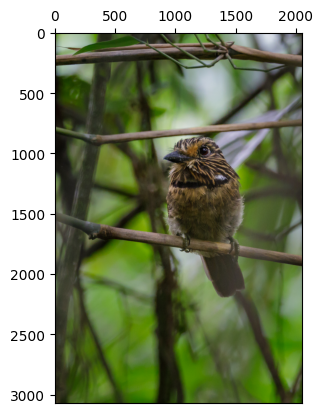

In [65]:
#| label: fig-01-natureza
#| fig-cap: "Área de Proteção Ambiental Quilombos do Médio Ribeira - Barbudo-rajado (Malacoptila striata). Crédito: Thomas Fuhrmann (CC BY-SA 4.0)."
#| echo: true

import requests
from PIL import Image
from PIL.ExifTags import TAGS
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/c/c5/Area_de_Prote%C3%A7%C3%A3o_Ambiental_Quilombos_do_M%C3%A9dio_Ribeira_-_Thomas-Fuhrmann_%282023-_02%29_Malacoptila_striata.jpg"

# Download e leitura do cabeçalho EXIF
res = requests.get(url, headers={'User-Agent': 'PDI-Book/1.0'})
img_pil = Image.open(BytesIO(res.content))
exif = img_pil._getexif()

if exif:
    # 1. Extração de Hardware e Tempo
    dados = {TAGS[k]: v for k, v in exif.items() if k in TAGS and TAGS[k] in ['Make', 'Model', 'DateTime']}
    print(f"Hardware/Tempo: {dados}")

    # 2. Processamento de GPS com conversão para float
    gps = exif.get(34853) 
    if gps:
        # Lambda convertendo frações para float para evitar erro de formatação
        to_dec = lambda dms, ref: float(-(dms[0]+dms[1]/60+dms[2]/3600) if ref in 'SW' else (dms[0]+dms[1]/60+dms[2]/3600))
        
        lat, lon = to_dec(gps[2], gps[1]), to_dec(gps[4], gps[3])
        print(f"GPS Decimal: {lat:.6f}, {lon:.6f}")

mm.show(img_pil)



---

## 2.7. Transformações Geométricas Básicas

As transformações geométricas alteram a posição dos pixels, mantendo os valores de intensidade. São fundamentais para alinhamento, correção de distorções e aumento de dados.

### 2.7.1. Translação

Desloca a imagem em \(t_x\) e \(t_y\) pixels:

Na prática, cria‑se uma nova imagem maior e copia‑se os pixels deslocados. Pixels que saem da área original são descartados e áreas vazias são preenchidas (geralmente com 0 – preto).

### 2.7.2. Rotação

Gira a imagem em torno da origem (ou de seu centro) por um ângulo \(\theta\). A transformação direta pode produzir buracos; na prática, usa‑se a transformação inversa (mapeamento de cada pixel da imagem destino para a origem) e interpolação (vizinho mais próximo, bilinear, bicúbica). A rotação geralmente requer redimensionamento da imagem para que nenhuma área seja cortada.

### 2.7.3. Escala (redimensionamento)

Altera o tamanho da imagem pelo fator \(s_x\) (horizontal) e \(s_y\) (vertical). O redimensionamento exige interpolação:

- **Vizinho mais próximo:** rápido, mas produz efeito de blocos.
- **Bilinear:** suaviza melhor, é um bom compromisso.
- **Bicúbica:** mais suave, usada em softwares profissionais.

A biblioteca `morph` oferece funções como `mm.resize(img, scale, interpolation)` e `mm.rotate(img, angle, center, interp)`.

---

## 2.8. Laboratório Prático: Visualizando Efeitos da Amostragem e Quantização

Neste experimento, vamos explorar como a redução da resolução espacial e da profundidade de bits afetam a qualidade visual.

### 2.8.1. Código para subamostragem (redução de resolução)

```python
import numpy as np
import matplotlib.pyplot as plt
import morph

# Carregar uma imagem (ex.: Lenna)
img = mm.read('https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png')
img_gray = mm.rgb2gray(img)

# Função para subamostrar por fator (ex.: 2, 4, 8)
def subsample(image, factor):
    h, w = image.shape
    new_h, new_w = h // factor, w // factor
    # Criar imagem reduzida: pegar um pixel a cada 'factor'
    reduced = image[::factor, ::factor]
    # Redimensionar de volta ao tamanho original para comparação (interpolação vizinho mais próximo)
    return mm.resize(reduced, (h, w), method='nearest')

plt.figure(figsize=(15, 5))
factors = [1, 2, 4, 8]
for i, f in enumerate(factors):
    sub = subsample(img_gray, f)
    plt.subplot(1, 4, i+1)
    mm.imshow(sub)
    plt.title(f'Fator = {f}')
plt.show()
```

### 2.8.2. Código para redução da profundidade de bits (quantização)

```python
def quantize(image, bits):
    """Reduz a imagem para 2^bits níveis de cinza."""
    levels = 2 ** bits
    # Normalizar, quantizar e denormalizar
    return np.floor(image / 256 * levels) / levels * 255

plt.figure(figsize=(15, 5))
bits = [8, 4, 2, 1]
for i, b in enumerate(bits):
    quant = quantize(img_gray, b)
    plt.subplot(1, 4, i+1)
    mm.imshow(quant)
    plt.title(f'{b} bits ({2**b} níveis)')
plt.show()
```

### 2.8.3. Discussão dos resultados

- **Subamostragem (fator 8):** observa‑se o efeito de *aliasing* – bordas serrilhadas e perda de detalhes finos. Em fator 4 já se nota blocos, mas a imagem ainda é reconhecível.
- **Quantização com 1 bit:** a imagem vira preto e branco, perde‑se totalmente a graduação de tons. Com 2 bits (4 níveis) ainda se percebe um efeito de “posters”, mas a silhueta geral se mantém. Com 4 bits (16 níveis) a qualidade é razoável; o olho humano dificilmente distingue 8 bits de 16 bits em imagens comuns.

Esses experimentos mostram o compromisso entre qualidade e custo de armazenamento, essencial para sistemas de processamento e compressão.

---

## 2.9. Exercícios Propostos

1. **Amostragem** – Carregue uma imagem, aplique subamostragem com fatores 2, 3 e 5. Compare visualmente e calcule o fator de redução no número de pixels.
2. **Quantização** – Implemente uma função que reduza a imagem a 3 bits (8 níveis). Visualize e descreva o ruído introduzido.
3. **Conectividade** – Escreva um código que identifique componentes conexas em uma imagem binária usando vizinhança‑4 e vizinhança‑8. Explique as diferenças.
4. **Transformação geométrica** – Aplique rotação de 30° e 45° em uma imagem, utilizando interpolação bilinear. Compare com a rotação sem interpolação (vizinho mais próximo) e comente sobre a suavidade.

---

## 2.10. Referências

- GONZALEZ, R. C.; WOODS, R. E. *Processamento Digital de Imagens*. 3. ed. Pearson, 2010.
- SZELISKI, R. *Computer Vision: Algorithms and Applications*. Springer, 2010.
- Otsu, N. (1979). *A threshold selection method from gray‑level histograms*. IEEE Trans. Syst. Man Cybern., 9(1), 62–66. (citado no Capítulo 1).

---

**Nota:** As operações de convolução, filtragem e morfologia matemática (erosão, dilatação) serão tratadas no **Capítulo 3 – Operações Espaciais em Imagens**. O presente capítulo concentrou‑se na formação, digitalização e topologia básica da imagem.

## Objetivos

Ao final deste capítulo, o aluno será capaz de:

- Compreender a representação matemática de imagens $f(x,y)$
- Ler, exibir e salvar imagens
- Trabalhar com imagens binárias, tons de cinza e coloridas (RGB)
- Acessar e modificar pixels individualmente

## O que é uma Imagem Digital?

Uma imagem digital é uma função discreta:

$$f: \mathbb{Z}^2 \rightarrow \mathbb{Z}^k
$$ {#eq-1-imagem}

onde $(x,y)$ são coordenadas espaciais e $f(x,y)$ é a intensidade do pixel.
Para imagens em **tons de cinza** $k=1$ com valores em $[0, 255]$;
para imagens **coloridas** (RGB) $k=3$, ver @fig-1-representacao.


::: {#fig-1-representacao}

![](imagens/lena.jpg){width=70% fig-align="center"}

Exemplo de Transformação Não Linear do Espaço de Entrada para o Espaço de Características.

:::


## Configuração do Ambiente


In [ ]:
# Instalação (Google Colab — executar uma vez)
# !pip install opencv-python-headless scikit-image matplotlib numpy

import sys
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, '../../morph')
import morph
importlib.reload(morph)
from morph import mm

print(f'OpenCV {cv2.__version__} | NumPy {np.__version__}')
print("Carregando imagem...")
print(help(mm.show))

## 1.3 Lendo e Exibindo Imagens

A operação mais básica em PDI é a leitura de uma imagem.
A função `mm.read()` da `morph.py` aceita caminhos locais e URLs.


In [ ]:
#| quarto-raw: false
#| label: fig-1-lena
#| fig-cap: "MVS Linear — Margem Máxima entre Íris Setosa e Versicolor (atributos de pétala)."
#| echo: true
#| output: true

import urllib.request, os

# Baixar imagem de exemplo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
os.makedirs('imagens', exist_ok=True)
if not os.path.exists('imagens/lena.jpg'):
    urllib.request.urlretrieve(url, 'imagens/lena.jpg')

# Ler imagem com morph.py
img = mm.read('imagens/lena.jpg')

print(f'Shape  : {img.shape}')    # (altura, largura, canais)
print(f'Dtype  : {img.dtype}')    # uint8
print(f'Min/Max: {img.min()} / {img.max()}')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mm.show(img_rgb, title='Imagem original')

## 1.4 Tipos de Imagem

### 1.4.1 Conversão para Tons de Cinza

A conversão de RGB para tons de cinza aplica pesos perceptuais definidos pela ITU-R BT.601:

$$g = 0.299\,R + 0.587\,G + 0.114\,B$$ {#eq-1-cinza}


In [ ]:
# Converter para tons de cinza
img_gray = mm.gray(img)
print(f'Shape cinza: {img_gray.shape}')

mm.show([img, img_gray], title=['Original (RGB)', 'Tons de Cinza'])

### 1.4.2 Limiarização (Binarização)

A limiarização converte uma imagem em tons de cinza para binária:

$$g(x,y) = \begin{cases} 255 & \text{se } f(x,y) \geq T \\ 0 & \text{caso contrário} \end{cases}$$ {#eq-1-limiar}

O método de **Otsu** [@otsu1979] determina $T$ automaticamente maximizando
a variância inter-classes do histograma.


In [ ]:
# Limiarização com T fixo
T = 128
img_bin = mm.threshold(img_gray, T)

# Limiarização Otsu (T automático)
_, img_otsu = cv2.threshold(img_gray, 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'Valores únicos (T={T}): {sorted(set(img_bin.flatten()))}')

mm.show([img_gray, img_bin, img_otsu],
        title=[f'Cinza', f'Binária (T={T})', 'Otsu'])

## 1.5 Acesso a Pixels

Em Python/NumPy, o acesso a pixels usa indexação de arrays `img[linha, coluna]`.


In [ ]:
r, c = 100, 100

# Acessar pixel
pixel_cinza = img_gray[r, c]
pixel_rgb   = img[r, c]       # array [R, G, B]

print(f'Pixel cinza ({r},{c}): {pixel_cinza}')
print(f'Pixel RGB   ({r},{c}): R={pixel_rgb[0]}  G={pixel_rgb[1]}  B={pixel_rgb[2]}')

# Imagem sintética 5×5 com pixel central branco
syn = np.zeros((5, 5), dtype=np.uint8)
syn[2, 2] = 255
print('\nMatriz 5×5:')
print(syn)

## 1.6 Resumo

Neste capítulo foram apresentados os fundamentos de representação de imagens digitais:

- Imagem digital = função $f(x,y)$ mapeando coordenadas para intensidades
- Tipos: binária ($k=1$, $\{0,255\}$), tons de cinza ($k=1$, $[0,255]$), RGB ($k=3$)
- `morph.py`: biblioteca didática que simplifica operações de PDI em Python
- Limiarização: operação fundamental de binarização

O Capítulo 2 estuda **histogramas e equalização**.

### Questões de Revisão

1. Qual a diferença entre imagem em tons de cinza e imagem binária?
2. Como o método de Otsu determina o limiar $T$ automaticamente?
3. O que representa `img.shape` para uma imagem NumPy RGB?

